# Building a point-in-time factor library

Equity factors die by lookahead. A B/P ratio computed with a book value the
market had not seen yet will backtest beautifully and trade terribly.

This recipe builds three classic factors and evaluates them honestly:

1. join fundamentals **as of their report date** with `asof_join`,
2. assemble value (B/P), momentum (12-1) and a quality proxy from
   revenue-growth stability,
3. evaluate them with monthly ICs and quintile spreads,
4. persist the result as a versioned, snapshotted factor panel.

That last step is the "factor library" pattern, where every rebuild is a
commit you can diff and pin.

## Terms used here

| term            | meaning |
| --------------- | --- |
| factor          | a characteristic shared across assets that explains returns, e.g. value or momentum |
| value (B/P)     | book value divided by price; high means cheap relative to accounting worth |
| quality         | a profitability or stability measure; here revenue-growth stability |
| momentum (12-1) | the return over the last twelve months, excluding the most recent one |
| panel           | a dataset with one row per asset per date |
| point-in-time   | data stored and queried as it was known at each moment |
| lookahead bias  | using information the strategy could not have had; the bug that kills factors |
| IC              | information coefficient: correlation between a signal and the return that followed |
| quintile spread | top fifth minus bottom fifth by signal, a model-free readout of whether it works |

New to any of these? [GLOSSARY.md](../../GLOSSARY.md) defines them at more
length, along with every other term the cookbook uses.

In [1]:
import numpy as np
import pandas as pd
import pyarrow as pa
from scipy import stats

import h5i_db
from h5i_db import col, count_star, sql_expr, time_bucket
import cookbook_utils as cu

db = h5i_db.Database(cu.fresh_db("alpha_factors"), create=True)

## 1. The data

Two feeds for 50 synthetic names. The price side is a daily OHLCV panel from
`cu.make_daily_prices`, roughly three years, one row per symbol per session.

| column | type | meaning |
| --- | --- | --- |
| `ts` | `timestamp[us, tz=UTC]` | session close, 20:00 UTC |
| `symbol` | `string` | ticker, `STK000` … `STK049` |
| `open`, `high`, `low`, `close` | `float64` | session prices |
| `volume` | `int64` | shares traded |

In [2]:
prices = cu.make_daily_prices()   # 50 symbols, 750 sessions
print(f"prices: {prices.num_rows:,} rows x {prices.num_columns} columns")
prices.to_pandas().head()

prices: 37,500 rows x 7 columns


,ts,symbol,open,high,low,close,volume
0,2023-01-02 20:00:00+00:00,STK000,300.49,301.15,300.41,300.64,567724
1,2023-01-02 20:00:00+00:00,STK001,79.08,79.65,79.08,79.58,410609
2,2023-01-02 20:00:00+00:00,STK002,45.75,46.16,45.71,45.88,306313
3,2023-01-02 20:00:00+00:00,STK003,27.24,27.52,27.23,27.31,392398
4,2023-01-02 20:00:00+00:00,STK004,108.79,108.81,108.11,108.51,888641


The fundamentals side is 12 quarters from `cu.make_fundamentals`, where `ts`
is the **report** timestamp, 25 to 55 days after `period_end`, like real
filings.

| column | type | meaning |
| --- | --- | --- |
| `ts` | `timestamp[us, tz=UTC]` | report time: when the numbers went public |
| `period_end` | `timestamp[us, tz=UTC]` | fiscal quarter end |
| `symbol` | `string` | ticker |
| `eps` | `float64` | reported earnings per share |
| `revenue_m`, `book_value_m` | `float64` | revenue and book value, USD millions |

Keeping the two feeds in separate tables with their own time semantics is what
makes point-in-time joins possible at all.

In [3]:
funda = cu.make_fundamentals()    # 50 symbols, 12 quarters, report-lagged ts
print(f"fundamentals: {funda.num_rows:,} rows x {funda.num_columns} columns")
funda.to_pandas().head()

fundamentals: 600 rows x 6 columns


,ts,period_end,symbol,eps,revenue_m,book_value_m
0,2023-04-25 21:00:00+00:00,2023-03-31 00:00:00+00:00,STK041,3.41,12654.6,10393.0
1,2023-04-25 21:00:00+00:00,2023-03-31 00:00:00+00:00,STK046,1.46,10266.5,6380.3
2,2023-04-26 21:00:00+00:00,2023-03-31 00:00:00+00:00,STK005,0.89,8136.4,9297.1
3,2023-04-26 21:00:00+00:00,2023-03-31 00:00:00+00:00,STK014,3.31,6959.7,10927.5
4,2023-04-26 21:00:00+00:00,2023-03-31 00:00:00+00:00,STK025,3.41,1031.1,1605.8


In [4]:
px_schema = pa.schema(
    [pa.field("ts", pa.timestamp("us", tz="UTC"), nullable=False)]
    + [prices.schema.field(i) for i in range(1, len(prices.schema))]
)
db.create_table("prices", px_schema, time_column="ts", sort_key=["ts", "symbol"])
db.append("prices", prices.sort_by([("ts", "ascending"), ("symbol", "ascending")]))

f_schema = pa.schema(
    [pa.field("ts", pa.timestamp("us", tz="UTC"), nullable=False)]
    + [funda.schema.field(i) for i in range(1, len(funda.schema))]
)
db.create_table("fundamentals", f_schema, time_column="ts", sort_key=["ts", "symbol"])
db.append("fundamentals", funda.sort_by([("ts", "ascending"), ("symbol", "ascending")]))
print(f"prices: {prices.num_rows:,} rows   fundamentals: {funda.num_rows:,} rows")

prices: 37,500 rows   fundamentals: 600 rows


## 2. Derived fundamental signals, per report date

Quality here means *stability* of quarterly revenue growth: the negated stddev
of the last four quarter-over-quarter growth rates.

Both the growth and its trailing stddev are window functions over the
report-time series, so this is one SQL statement. We store its output as its
own table, `fund_signals`. Derived data is data, and it should be versioned
like everything else.

In [5]:
PREV_REV = sql_expr("lag(revenue_m)").over(partition_by="symbol", order_by="ts")

fund_sig = (
    db.table("fundamentals")
    .with_columns(rev_g=col("revenue_m") / PREV_REV - 1)
    .with_columns(
        rev_g_std=col("rev_g").rolling_std(4, order_by="ts", partition_by="symbol"),
        n_g=col("rev_g").rolling_count(4, order_by="ts", partition_by="symbol"),
    )
    .select("ts", "symbol", "book_value_m", "rev_g", "rev_g_std", "n_g")
    .sort(["ts", "symbol"])
    .to_arrow()
)

fs_schema = pa.schema(
    [
        pa.field("ts", pa.timestamp("us", tz="UTC"), nullable=False),
        pa.field("symbol", pa.string()),
        pa.field("book_value_m", pa.float64()),
        pa.field("rev_g", pa.float64()),
        pa.field("rev_g_std", pa.float64()),
        pa.field("n_g", pa.int64()),
    ]
)
db.create_table("fund_signals", fs_schema, time_column="ts", sort_key=["ts", "symbol"])
db.append("fund_signals", fund_sig.cast(fs_schema), note="rev growth + 4q stability")

{'table': 'fund_signals',
 'sequence': 1,
 'op': 'append',
 'rows_total': 600,
 'segments_total': 1,
 'segments_added': 1,
 'segments_deduped': 0,
 'committed_at_ns': 1785437911305642491}

## 3. Month-end price panel with momentum

Same pattern as the momentum recipe: `lag(21)/lag(252)` per symbol for 12-1
momentum, sampled on the last trading day of each month via
`time_bucket('1mo', ...)`.

This panel also gets stored. `asof_join` operates on tables, and month-end
observation dates are exactly the left side we want fundamentals attached to.

In [6]:
def lag_close(n: int):
    return sql_expr(f"lag(close, {n})").over(partition_by="symbol", order_by="ts")


sig = db.table("prices").with_columns(px_1m_ago=lag_close(21), px_12m_ago=lag_close(252))

month_end = (
    db.table("prices")
    .group_by(time_bucket("1mo", col("ts")).alias("month"), "symbol")
    .agg(month_end=col("ts").max())
    .select(col("month_end").alias("ts"), "symbol")
)

panel_tbl = (
    sig.join(month_end, on=["ts", "symbol"])
    .select(
        ts=col("ts", relation="l"),
        symbol=col("symbol", relation="l"),
        close=col("close", relation="l"),
        momentum=col("px_1m_ago", relation="l") / col("px_12m_ago", relation="l") - 1,
    )
    .sort(["ts", "symbol"])
    .to_arrow()
)

panel_schema = pa.schema(
    [
        pa.field("ts", pa.timestamp("us", tz="UTC"), nullable=False),
        pa.field("symbol", pa.string()),
        pa.field("close", pa.float64()),
        pa.field("momentum", pa.float64()),
    ]
)
db.create_table("panel_me", panel_schema, time_column="ts", sort_key=["ts", "symbol"])
db.append("panel_me", panel_tbl.cast(panel_schema), note="month-end closes + 12-1 momentum")
db.table("panel_me").select(rows=count_star(), months=col("ts").n_unique()).to_pandas()

,rows,months
0,1750,35


## 4. The point-in-time join

`asof_join('panel_me', 'fund_signals', 'ts', 'ts', 'symbol')` gives, for every
month-end row, the latest fundamental row **reported at or before** that date,
per symbol.

There is no calendar arithmetic and no "shift the quarter by 45 days"
heuristic. The report timestamp is the join key, so restatement lags are
handled by construction.

`ts_right` shows exactly which filing each month used, and months before a
symbol's first report get NULLs, as they should.

In [7]:
pit = (
    db.table("panel_me")
    .join_asof(db.table("fund_signals"), on="ts", by="symbol")
    .select("ts", "symbol", "close", "momentum", "book_value_m", "rev_g_std", "n_g",
            report_ts=col("ts_right"))
    .sort(["ts", "symbol"])
    .to_pandas()
)
pit["staleness_days"] = (pit["ts"] - pit["report_ts"]).dt.days
pit[["ts", "symbol", "close", "momentum", "book_value_m", "report_ts", "staleness_days"]].tail(4)

,ts,symbol,close,momentum,book_value_m,report_ts,staleness_days
1746,2025-11-14 20:00:00+00:00,STK046,281.06,0.680306,6163.4,2025-08-17 21:00:00+00:00,88.0
1747,2025-11-14 20:00:00+00:00,STK047,1111.96,1.006184,37242.0,2025-11-07 21:00:00+00:00,6.0
1748,2025-11-14 20:00:00+00:00,STK048,258.40,0.154716,10124.7,2025-11-11 21:00:00+00:00,2.0
1749,2025-11-14 20:00:00+00:00,STK049,187.16,0.928015,14619.8,2025-10-31 21:00:00+00:00,13.0


## 5. Assemble the three factors

- **value**: B/P, book value over market cap, with a fixed synthetic share
  count per symbol. The generator has no shares outstanding, and a static,
  seeded share count keeps the cross-section meaningful and deterministic.
- **momentum**: 12-1, straight from the panel.
- **quality**: the negated stddev of the last 4 revenue growth rates, required
  complete (`n_g = 4`).

Each factor is cross-sectionally z-scored per month and clipped at ±3, which
makes them comparable and combinable.

In [8]:
rng = np.random.default_rng(123)
symbols = sorted(pit["symbol"].unique())
shares_m = dict(zip(symbols, rng.uniform(100, 2000, len(symbols)).round(1)))

pit["value"] = pit["book_value_m"] / (pit["close"] * pit["symbol"].map(shares_m))
pit["quality"] = np.where(pit["n_g"] == 4, -pit["rev_g_std"], np.nan)

FACTORS = ["value", "momentum", "quality"]


def zscore_by_month(df: pd.DataFrame, field: str) -> pd.Series:
    g = df.groupby("ts")[field]
    return ((df[field] - g.transform("mean")) / g.transform("std")).clip(-3, 3)


for f in FACTORS:
    pit[f"z_{f}"] = zscore_by_month(pit, f)
pit["z_combo"] = pit[[f"z_{f}" for f in FACTORS]].mean(axis=1)

coverage = pit.groupby("ts")[[f"z_{f}" for f in FACTORS]].count()
coverage.tail(3)

,z_value,z_momentum,z_quality
ts,,,
2025-09-30 20:00:00+00:00,50,50,50
2025-10-31 20:00:00+00:00,50,50,50
2025-11-14 20:00:00+00:00,50,50,50


## 6. Evaluation: information coefficients and quintile spreads

The IC is the monthly Spearman rank correlation between the factor value at
month-end *t* and the return over month *t+1*. The signal is fully observable
before the return begins.

A |t-stat| above roughly 2 on the mean IC is the usual bar for "this factor
predicts something".

In [9]:
close_piv = pit.pivot(index="ts", columns="symbol", values="close")
fwd_ret = close_piv.pct_change().shift(-1)
pit = pit.merge(
    fwd_ret.stack().rename("fwd_ret").reset_index().rename(columns={"level_1": "symbol"}),
    on=["ts", "symbol"],
    how="left",
)


def monthly_ic(df: pd.DataFrame, field: str) -> pd.Series:
    out = {}
    for ts, g in df.dropna(subset=[field, "fwd_ret"]).groupby("ts"):
        if len(g) >= 20:
            out[ts] = stats.spearmanr(g[field], g["fwd_ret"])[0]
    return pd.Series(out, name=field)


ics = pd.concat([monthly_ic(pit, f"z_{f}") for f in FACTORS + ["combo"]], axis=1)
ic_summary = pd.DataFrame(
    {
        "mean_IC": ics.mean(),
        "IC_vol": ics.std(),
        "t_stat": ics.mean() / ics.std() * np.sqrt(ics.notna().sum()),
        "months": ics.notna().sum(),
    }
)
ic_summary.round(3)

,mean_IC,IC_vol,t_stat,months
z_value,-0.009,0.164,-0.313,30
z_momentum,0.077,0.139,2.669,23
z_quality,-0.100,0.136,-3.139,18
z_combo,-0.041,0.145,-1.546,30


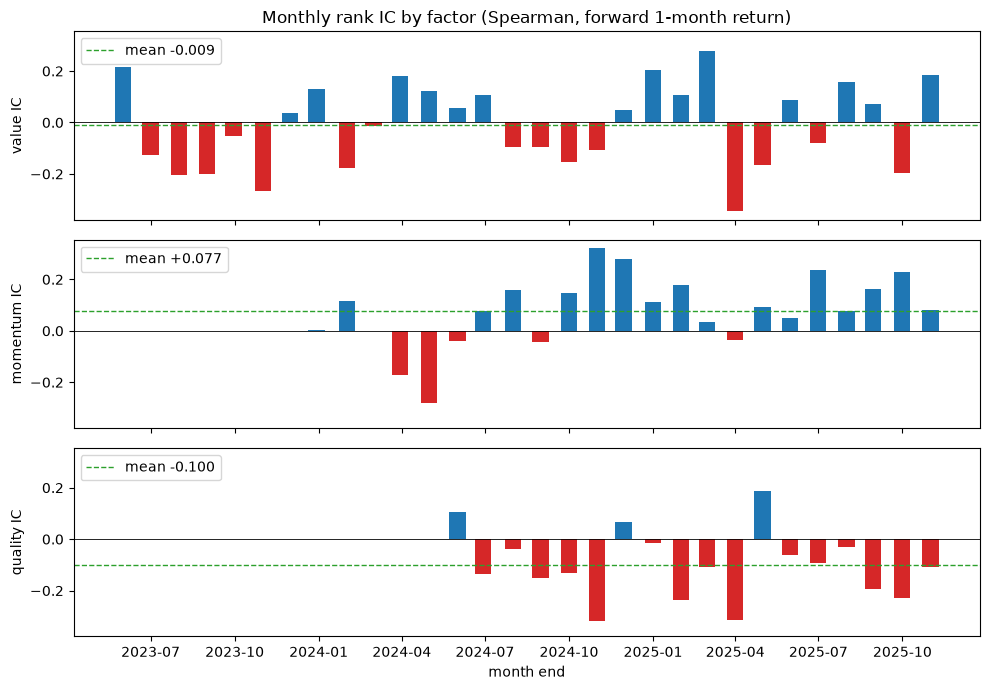

In [10]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True, sharey=True)
for ax, f in zip(axes, FACTORS):
    s = ics[f"z_{f}"].dropna()
    ax.bar(s.index, s.values, width=18, color=np.where(s.values >= 0, "tab:blue", "tab:red"))
    ax.axhline(0, color="black", lw=0.6)
    ax.axhline(s.mean(), color="tab:green", lw=1.0, ls="--", label=f"mean {s.mean():+.3f}")
    ax.set_ylabel(f"{f} IC")
    ax.legend(loc="upper left")
axes[0].set_title("Monthly rank IC by factor (Spearman, forward 1-month return)")
axes[-1].set_xlabel("month end")
fig.tight_layout()

Quintile spreads give the same information in return space. Sort into five
10-name buckets each month, hold equal-weight for one month, and look at
Q5 minus Q1.

In [11]:
def quintile_spread(df: pd.DataFrame, field: str) -> pd.Series:
    out = {}
    for ts, g in df.dropna(subset=[field, "fwd_ret"]).groupby("ts"):
        if len(g) >= 25:
            q = pd.qcut(g[field].rank(method="first"), 5, labels=False)
            out[ts] = g["fwd_ret"][q == 4].mean() - g["fwd_ret"][q == 0].mean()
    return pd.Series(out)


spreads = pd.DataFrame({f: quintile_spread(pit, f"z_{f}") for f in FACTORS + ["combo"]})
pd.DataFrame(
    {
        "ann_spread": spreads.mean() * 12,
        "t_stat": spreads.mean() / spreads.std() * np.sqrt(spreads.notna().sum()),
    }
).round(3)

,ann_spread,t_stat
value,-0.030,-0.506
momentum,0.170,2.144
quality,-0.202,-2.825
combo,-0.053,-0.793


Read the numbers for what they are. This is where synthetic data teaches the
most.

- **Momentum** is genuinely positive, with an IC t of about 2.7 and a
  double-digit annualized Q5−Q1 spread. The generator gives each name a
  persistent drift, so past winners keep winning, and the pipeline detects a
  real effect.
- **Value** is correctly a null. The cross-sectional B/P ranking is dominated
  by each name's static book and shares draw, which carries no information
  about future returns.
- **Quality** is the trap. Its mean IC has a |t| of about 3, yet the factor is
  built from *pure noise*, since every name has identical revenue-growth vol
  by construction. The trailing 4-quarter window makes this month's factor
  nearly identical to last month's, so the roughly 18 monthly ICs are one or
  two effective observations wearing eighteen hats, and the i.i.d. t-stat is
  fiction. Slow-moving signals need overlap-robust inference, whether
  Newey-West or non-overlapping windows, before you believe any t-stat.

The combo inherits the noise it averages in. On 20 to 30 months, none of this
would clear a research bar on real data. The pipeline, not the alphas, is the
deliverable.

## 7. Persist the panel: the factor library pattern

The finished panel, raw factors plus z-scores, becomes a `factor_panel` table.
The snapshot names the state of *every* table that produced it.

Rebuild the library next month and you get a new version to diff. Pin a paper
or a production model to the snapshot it was trained on.

In [12]:
out_cols = ["ts", "symbol", "value", "momentum", "quality", "z_value", "z_momentum", "z_quality", "z_combo"]
panel_out = pit[out_cols].sort_values(["ts", "symbol"])

fp_schema = pa.schema(
    [pa.field("ts", pa.timestamp("us", tz="UTC"), nullable=False), pa.field("symbol", pa.string())]
    + [pa.field(c, pa.float64()) for c in out_cols[2:]]
)
db.create_table("factor_panel", fp_schema, time_column="ts", sort_key=["ts", "symbol"])
db.append(
    "factor_panel",
    pa.Table.from_pandas(panel_out, preserve_index=False).cast(fp_schema),
    note="build 001: value/momentum/quality + combo",
)
db.snapshot(
    "factor-build-001",
    tables=["prices", "fundamentals", "fund_signals", "panel_me", "factor_panel"],
    note="monthly factor library build",
)

(
    db.table("factor_panel", snapshot="factor-build-001")
    .group_by("ts")
    .agg(names=count_star(), combo_mean=col("z_combo").mean(), mom_z_std=col("z_momentum").std())
    .sort("ts", descending=True)
    .limit(3)
    .to_pandas()
).set_index("ts").round(3)

,names,combo_mean,mom_z_std
ts,,,
2025-11-14 20:00:00+00:00,50,-0.011,1.0
2025-10-31 20:00:00+00:00,50,-0.009,1.0
2025-09-30 20:00:00+00:00,50,-0.012,1.0


## Takeaways

- `asof_join` on the **report timestamp** is the whole point-in-time
  machinery. Every month-end row picks up the latest filing the market had
  actually seen, and `ts_right` documents which one.
- Derived data is data. Growth and stability signals, the month-end panel and
  the final factor library all live as versioned h5i tables, built by SQL
  windows: `lag`, `stddev ... OVER ROWS`, `time_bucket('1mo')`.
- The evaluation is honest on synthetic data. Momentum works because drift is
  persistent by construction, value is a null, and quality's "significant"
  t-stat is an overlapping-window artifact built from pure noise. That is the
  cheapest lesson in factor-research inference you will ever get.
- One `db.snapshot(...)` pins the *entire* input lineage of a factor build.
  "Which fundamentals produced the panel my model trained on?" becomes a
  query rather than an investigation.

In [13]:
db.close()